# Triaje automático de literatura biomédica

### Clasificación de abstracts médicos en cinco áreas clínicas

Grupo Tango:
- Gustavo Betancur
- Mike Martinez
- Pedro Jojoa
- Juan Sebastian Orozco

**Sesión 1 — Embeddings y redes recurrentes** · MIIA, Universidad Icesi


---

**Contenido de esta entrega:**

| Sección | Contenido |
|---|---|
| 1 | Planteamiento del problema e hipótesis (H1–H3) |
| 2 | Andamiaje reproducible: semillas, split estratificado, métrica única |
| 3 | Análisis exploratorio: cada gráfica fija una decisión posterior |
| 4 | Síntesis: los hiperparámetros que el EDA deja decididos |
| 5–6 | Baselines (B0, B1), LSTM de referencia (E1) y contraste de resultados |
| 7 | Conclusiones y siguientes pasos |

Los embeddings pre-entrenados (E2–E4) y las ablaciones quedan para la siguiente entrega.

---

## 1. El problema

### 1.1 Qué se decide

Un *abstract* biomédico llega sin etiquetar y hay que enrutarlo a una de cinco áreas clínicas:

| Etiqueta | Área |
|---|---|
| 1 | Neoplasias |
| 2 | Enfermedades del sistema digestivo |
| 3 | Enfermedades del sistema nervioso |
| 4 | Enfermedades cardiovasculares |
| 5 | Condiciones patológicas generales |

Es el **triaje de literatura**: PubMed indexa más de un millón de artículos al año y
alguien tiene que decidir a qué área va cada uno. Automatizar ese primer filtro libera el
tiempo del revisor para los casos dudosos.

### 1.2 Tres propiedades del dominio

Al revisar el corpus notamos tres cosas que condicionan todo lo que viene después:

- **El vocabulario *es* la señal.** Lo que decide la clase son términos como `restenosis` o
  `cholangiocarcinoma`, no el tema general. Si el modelo pierde ese vocabulario, pierde todo
  (lo medimos en §3.4).
- **Hay una clase cajón de sastre.** "Condiciones patológicas generales" no es un área
  anatómica: recoge lo que no encaja en las otras cuatro, así que comparte léxico con todas.
  Por eso la matriz de confusión nos va a interesar tanto como la métrica.
- **Las clases están desbalanceadas** (§3.1). Un modelo que responda siempre lo mismo acierta
  un tercio de las veces sin aprender nada — y reportar sólo *accuracy* lo haría ver bien.

### 1.3 Por qué probar una LSTM

Nuestro argumento a favor es la **negación y el alcance sintáctico**: *"sin evidencia de
metástasis"* y *"con evidencia de metástasis"* son idénticos para una bolsa de palabras, y un
modelo que lee en orden podría distinguirlos.

Dicho eso, no damos por hecho que gane: un abstract ronda las 180 palabras (secuencia larga
para una LSTM de una capa) y el desbalance castiga a las clases pequeñas. **La comparamos
contra TF-IDF y dejamos que los números decidan.** Si la bolsa de palabras gana, ese es el
hallazgo.

### 1.4 Hipótesis

Las escribimos **antes** de ver cualquier resultado, para no acomodar la explicación después:

> **H1 — Valor de la arquitectura secuencial.** Una LSTM supera a TF-IDF + regresión
> logística en macro-F1. *Refutable:* si TF-IDF iguala o gana, el costo computacional de
> la recurrencia no se justifica en este corpus.
>
> **H2 — Valor de los embeddings pre-entrenados.** Inicializar la capa de embedding con
> los vectores de spaCy mejora sobre inicializarla aleatoriamente. *Refutable:* si no hay
> diferencia, el corpus tiene suficiente señal para aprender sus propios vectores.
>
> **H3 — El dominio importa.** El beneficio de H2 se concentra en las clases con menor
> proporción de términos fuera del vocabulario de spaCy. *Refutable:* si la mejora es
> uniforme entre clases, la cobertura léxica no es el mecanismo.

H1 se contrasta en §6. H2 y H3 quedan para la entrega siguiente, con la evidencia descriptiva
que produce este notebook.

---

## 2. Andamiaje reproducible

Media hora de montaje que se paga sola: todo lo que viene después son comparaciones, y sin
estas cuatro piezas no comparan nada.

1. **Semilla global fija**, para que dos corridas del mismo modelo den el mismo número.
2. **Split estratificado**, porque con un desbalance de 3:1 un `random_split` deja
   proporciones distintas en cada partición y contamina las comparaciones posteriores.
3. **Una única función de evaluación**, para que ningún experimento se mida distinto.
4. **Un registro en CSV**, para que la tabla comparativa final se construya sola.

In [13]:
import os, re, random, warnings, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

DATA = Path("../data/medical_abstracts")
FIGS = Path("figuras");    FIGS.mkdir(exist_ok=True)
RES  = Path("resultados"); RES.mkdir(exist_ok=True)

print(f"semilla={SEED}   dispositivo={DEVICE}")

semilla=42   dispositivo=cpu


### 2.1 Estilo y paleta de las figuras

Todas las gráficas comparten una sola definición de estilo. La paleta se validó con el criterio
de separación perceptual para daltonismo (ΔE ≥ 8 en OKLab para el par adyacente, contraste ≥ 3:1
contra el fondo).

La regla en todo el notebook es que **el color codifica una sola cosa a la vez**: cuando se
comparan magnitudes entre categorías se usa un único tono, porque la etiqueta ya identifica la
categoría, y el naranja queda reservado para resaltar el elemento que discute el texto.

In [14]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, MALLA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.edgecolor": MALLA, "axes.linewidth": 1.0,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": MALLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, ejes=("top", "right")):
    """Quita marcos innecesarios: menos tinta que no es dato."""
    for e in ejes:
        ax.spines[e].set_visible(False)
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGS / f"{nombre}.png")
    return fig

### 2.2 Carga del corpus

El corpus es [`TimSchopf/medical_abstracts`](https://huggingface.co/datasets/TimSchopf/medical_abstracts)
(licencia CC-BY-SA 3.0), derivado de un subconjunto de PubMed. Trae partición oficial de
entrenamiento y prueba, y decidimos respetarla en lugar de inventar una propia: así los
resultados quedan comparables con otros trabajos sobre el mismo dataset.

In [15]:
# El corpus no se versiona en git (pesa ~10 MB). Si no está en local, se baja del Hub.
BASE_HUB = ("https://huggingface.co/datasets/TimSchopf/medical_abstracts/"
            "resolve/refs%2Fconvert%2Fparquet/")
FUENTES = {"train":  BASE_HUB + "default/train/0000.parquet",
           "test":   BASE_HUB + "default/test/0000.parquet",
           "labels": BASE_HUB + "labels/train/0000.parquet"}

DATA.mkdir(parents=True, exist_ok=True)
for nombre, url in FUENTES.items():
    destino = DATA / f"{nombre}.parquet"
    if not destino.exists():
        print(f"descargando {nombre}…")
        pd.read_parquet(url).to_parquet(destino, index=False)
print(f"corpus disponible en {DATA.resolve()}")

corpus disponible en C:\Users\pjojoa\Desktop\Entregable 1\NLP_MiniProyectos\data\medical_abstracts


In [16]:
etiquetas = pd.read_parquet(DATA / "labels.parquet")
NOMBRE = dict(zip(etiquetas.condition_label, etiquetas.condition_name))
CLASES = [NOMBRE[i] for i in sorted(NOMBRE)]

def cargar(particion):
    df = pd.read_parquet(DATA / f"{particion}.parquet")
    df = df.rename(columns={"medical_abstract": "texto", "condition_label": "y"})
    df["clase"] = df.y.map(NOMBRE)
    return df.reset_index(drop=True)

df_oficial_train, df_test = cargar("train"), cargar("test")

print(f"partición oficial de entrenamiento : {len(df_oficial_train):>6,}")
print(f"partición oficial de prueba        : {len(df_test):>6,}")
print(f"clases                             : {len(CLASES)}")
for i, c in sorted(NOMBRE.items()):
    print(f"   {i} · {c}")

partición oficial de entrenamiento : 11,550
partición oficial de prueba        :  2,888
clases                             : 5
   1 · neoplasms
   2 · digestive system diseases
   3 · nervous system diseases
   4 · cardiovascular diseases
   5 · general pathological conditions


In [17]:
# Un ejemplo, para ver con qué se está trabajando
ej = df_oficial_train.iloc[7]
print(f"CLASE: {ej.clase}\n")
print(textwrap.fill(ej.texto[:700], 92) + " […]")

CLASE: cardiovascular diseases

Pharmacomechanical thrombolysis and angioplasty in the management of clotted hemodialysis
grafts: early and late clinical results. The results of pharmacomechanical thrombolysis and
angioplasty of 121 thrombosed hemodialysis grafts were reviewed. The initial
pharmacomechanical method (used in 65 cases) employed clot maceration with hook-shaped
catheters and clot lacing with highly concentrated urokinase. The current technique (used in
56 cases) consisted of pulsed-spray injection of urokinase into the clot. All fully treated
grafts (117 cases) underwent complete or near-complete thrombolysis, and 93% remained patent
after 1 day. Mean time for pulsed-spray lysis was 46 minutes +/- 21. One pat […]


### 2.3 Split estratificado

La partición oficial de entrenamiento se divide en **entrenamiento (90%)** y
**validación (10%)**, estratificando por clase. La de prueba queda intacta y no se vuelve a
mirar hasta el final del modelado.

Dos cuidados que aquí sí importan:

- **`stratify=y`.** Con un desbalance de 3:1, un split aleatorio puede dejar la clase
  minoritaria mal representada en validación por puro azar, y entonces la métrica mide el
  sorteo tanto como el modelo.
- **El EDA se calcula sólo sobre entrenamiento.** Mirar validación o prueba para construir el
  vocabulario o fijar el `max_length` sería fuga de información: ajustaríamos decisiones a
  datos que el modelo no debería haber visto.

In [18]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_oficial_train, test_size=0.10, stratify=df_oficial_train.y, random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

reparto = pd.DataFrame({
    "train_%": df_train.clase.value_counts(normalize=True),
    "val_%":   df_val.clase.value_counts(normalize=True),
    "test_%":  df_test.clase.value_counts(normalize=True),
}).mul(100).round(2).loc[CLASES]
reparto["n_train"] = df_train.clase.value_counts().loc[CLASES]

print(f"train={len(df_train):,}   val={len(df_val):,}   test={len(df_test):,}\n")
print("Proporción de cada clase por partición:")
print(reparto.to_string())
print(f"\nDesviación máxima train↔val: "
      f"{(reparto['train_%'] - reparto['val_%']).abs().max():.2f} puntos porcentuales")

train=10,395   val=1,155   test=2,888

Proporción de cada clase por partición:
                                 train_%  val_%  test_%  n_train
clase                                                           
neoplasms                          21.90  21.90   21.92     2277
digestive system diseases          10.34  10.39   10.35     1075
nervous system diseases            13.33  13.33   13.33     1386
cardiovascular diseases            21.14  21.13   21.12     2197
general pathological conditions    33.29  33.25   33.28     3460

Desviación máxima train↔val: 0.05 puntos porcentuales


**Observación.** La desviación máxima entre entrenamiento y validación es de 0,05 puntos
porcentuales: la estratificación funcionó y las particiones son comparables.

### 2.4 La métrica, y por qué no es *accuracy*

Con la clase mayoritaria en un tercio del corpus, el *accuracy* premia a un modelo que ignore
las clases pequeñas. La métrica principal es **macro-F1**, que promedia el F1 de cada clase sin
ponderar por su tamaño: fallar en la minoritaria cuesta lo mismo que fallar en la mayoritaria.

El *accuracy* se reporta como dato secundario y siempre junto al piso de la clase mayoritaria,
para que se lea en contexto. Todo modelo del proyecto pasa por `evaluar()`, sin excepciones.

In [19]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, balanced_accuracy_score)

REGISTRO = RES / "experimentos.csv"

def evaluar(y_true, y_pred, nombre, particion="val", notas="", registrar=True, verbose=True):
    """Única función de evaluación del proyecto. Todos los modelos pasan por aquí."""
    m = {
        "experimento":  nombre,
        "particion":    particion,
        "macro_f1":     f1_score(y_true, y_pred, average="macro"),
        "weighted_f1":  f1_score(y_true, y_pred, average="weighted"),
        "accuracy":     accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "notas":        notas,
    }
    if verbose:
        print(f"── {nombre}  ({particion})")
        print(f"   macro-F1 {m['macro_f1']:.4f}   accuracy {m['accuracy']:.4f}   "
              f"bal-acc {m['balanced_acc']:.4f}\n")
        print(classification_report(y_true, y_pred, target_names=CLASES,
                                    digits=3, zero_division=0))
    if registrar:
        pd.DataFrame([m]).to_csv(REGISTRO, mode="a",
                                 header=not REGISTRO.exists(), index=False)
    m["confusion"] = confusion_matrix(y_true, y_pred)
    return m

# Piso de referencia: predecir siempre la clase mayoritaria.
mayoritaria = df_train.y.value_counts().idxmax()
_ = evaluar(df_val.y, np.full(len(df_val), mayoritaria),
            nombre="B0-clase-mayoritaria", particion="val",
            notas=f"predice siempre '{NOMBRE[mayoritaria]}'")

── B0-clase-mayoritaria  (val)
   macro-F1 0.0998   accuracy 0.3325   bal-acc 0.2000

                                 precision    recall  f1-score   support

                      neoplasms      0.000     0.000     0.000       253
      digestive system diseases      0.000     0.000     0.000       120
        nervous system diseases      0.000     0.000     0.000       154
        cardiovascular diseases      0.000     0.000     0.000       244
general pathological conditions      0.332     1.000     0.499       384

                       accuracy                          0.332      1155
                      macro avg      0.066     0.200     0.100      1155
                   weighted avg      0.111     0.332     0.166      1155



**Observación.** El piso y el argumento contra el *accuracy* caben en una tabla: el modelo vacío
alcanza **0,33 de accuracy**, que suena razonable, con un **macro-F1 de 0,10**. Esa segunda cifra
es la que hay que superar.

Nos parece revelador el `f1-score` de 0,000 en cuatro de las cinco clases: es exactamente lo que
el *accuracy* agregado esconde.

---

## 3. Análisis exploratorio

El criterio de esta sección es que **cada gráfica justifique una decisión posterior**, ninguna
es de adorno: la distribución de clases fija la métrica, las longitudes fijan `max_length`, la
curva de cobertura fija el tamaño del vocabulario y la medición de OOV decide si vale la pena
intentar el experimento de embeddings pre-entrenados.

Todo se calcula **sobre `df_train`**, nunca sobre validación o prueba.

### 3.1 Distribución de clases → fija la métrica

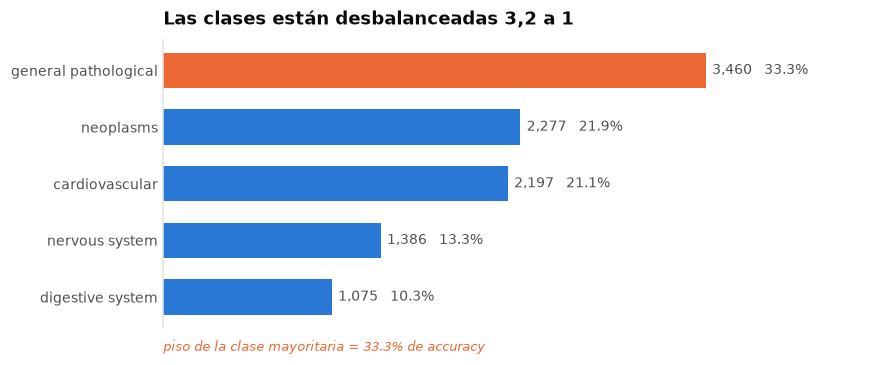

ratio mayoritaria/minoritaria = 3.22
piso de accuracy              = 0.3329


In [20]:
conteo = df_train.clase.value_counts().loc[CLASES].sort_values()
piso = conteo.max() / conteo.sum()

fig, ax = plt.subplots(figsize=(8.4, 3.4))
colores = [NARANJA if c == conteo.idxmax() else AZUL for c in conteo.index]
ax.barh(range(len(conteo)), conteo.values, color=colores, height=0.62)

ax.set_yticks(range(len(conteo)))
ax.set_yticklabels([c.replace(" diseases", "").replace(" conditions", "") for c in conteo.index])
for i, v in enumerate(conteo.values):
    ax.text(v + 40, i, f"{v:,}   {v/conteo.sum():.1%}", va="center", fontsize=9, color=TINTA_2)

ax.set_xlim(0, conteo.max() * 1.32)
ax.set_title("Las clases están desbalanceadas 3,2 a 1")
ax.xaxis.set_visible(False)
limpiar(ax, ("top", "right", "bottom"))
ax.text(0, -0.95, f"piso de la clase mayoritaria = {piso:.1%} de accuracy",
        fontsize=8.5, color=NARANJA, style="italic")
guardar(fig, "01-distribucion-clases"); plt.show()

print(f"ratio mayoritaria/minoritaria = {conteo.max()/conteo.min():.2f}")
print(f"piso de accuracy              = {piso:.4f}")

**Lectura.** El desbalance es moderado (3,22:1) pero suficiente para invalidar el *accuracy*:
*general pathological conditions* concentra un tercio de los datos y triplica a *digestive
system diseases*.

No es un accidente del muestreo sino una propiedad del esquema de etiquetado: las otras cuatro
clases son áreas anatómicas delimitadas y la mayoritaria es el residuo que recoge lo que no cae
limpiamente en ninguna. Nos preocupa porque un residuo grande y heterogéneo es justo el tipo de
clase que un modelo aprende a usar como respuesta por defecto: infla el *accuracy* y hunde el F1
de las clases pequeñas.

> **Decisión que fija:** macro-F1 como métrica principal, y pérdida ponderada por clase como
> variable a probar en la fase de modelado.

### 3.2 Longitud de los textos → fija `max_length`

Un error fácil de cometer aquí es medir las longitudes en caracteres y luego fijar el
`max_length` en tokens, mezclando dos unidades que no se convierten una en otra.

Por eso medimos en tokens, con el mismo tokenizador que usará el modelo, y elegimos el corte
mirando cuánto texto se pierde con cada opción.

In [21]:
def tokenizar(texto):
    """Mismo tokenizador que usará el modelo: minúsculas, alfanumérico."""
    return re.sub(r"[^a-z0-9]+", " ", texto.lower()).split()

df_train["tokens"] = df_train.texto.map(tokenizar)
df_train["n_tok"]  = df_train.tokens.map(len)
n_tok = df_train.n_tok

corte = pd.DataFrame([
    {"max_length": L,
     "docs_truncados_%":  (n_tok > L).mean() * 100,
     "tokens_perdidos_%": np.maximum(n_tok - L, 0).sum() / n_tok.sum() * 100}
    for L in (64, 128, 192, 256, 320, 384, 512)
]).round(1)

print(n_tok.describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]).round(1).to_string())
print()
print(corte.to_string(index=False))

count    10395.0
mean       185.4
std         79.7
min         26.0
5%          63.0
25%        125.0
50%        181.0
75%        243.0
90%        285.0
95%        316.0
99%        395.0
max        622.0

 max_length  docs_truncados_%  tokens_perdidos_%
         64              94.5               65.8
        128              73.9               36.6
        192              44.5               15.9
        256              20.0                4.8
        320               4.5                1.2
        384               1.3                0.2
        512               0.0                0.0


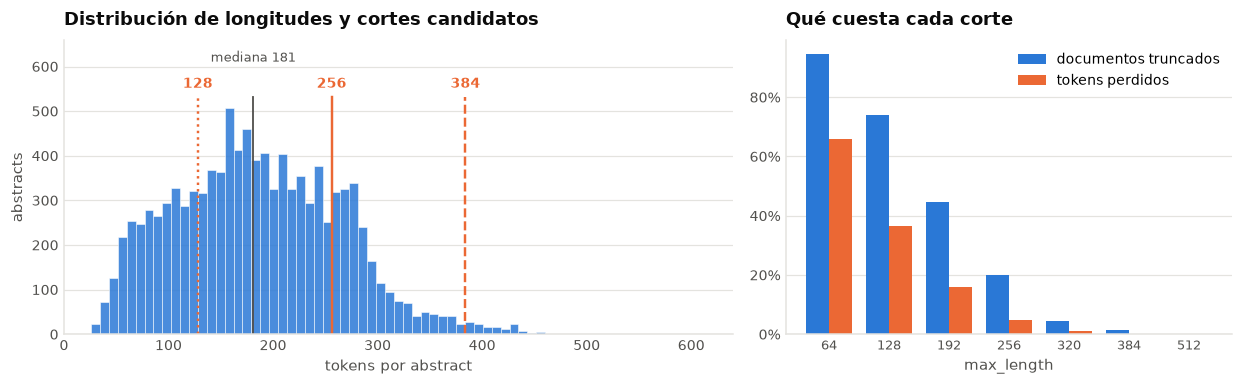

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 3.6),
                               gridspec_kw={"width_ratios": [1.5, 1]})

# — izquierda: distribución con los cortes candidatos
ax1.hist(n_tok, bins=70, color=AZUL, alpha=.85, edgecolor="white", linewidth=.4)
tope = ax1.get_ylim()[1]
ax1.set_ylim(0, tope * 1.24)          # espacio libre arriba para las etiquetas

# Los cortes candidatos. Las líneas se recortan justo debajo de la banda de etiquetas
# (ymax en fracción de eje) para que ninguna atraviese su propio rótulo.
TECHO = 1 / 1.24
for L, est in [(128, ":"), (256, "-"), (384, "--")]:
    ax1.axvline(L, ymax=TECHO, color=NARANJA, linestyle=est, linewidth=1.6)
    ax1.text(L, tope * 1.04, str(L), color=NARANJA, fontsize=9,
             fontweight="bold", ha="center")
# la mediana, una fila más arriba: así nunca choca con la etiqueta de 128
ax1.axvline(n_tok.median(), ymax=TECHO, color=TINTA_2, linewidth=1.2)
ax1.text(n_tok.median(), tope * 1.15, f"mediana {int(n_tok.median())}",
         color=TINTA_2, fontsize=8.5, ha="center")

ax1.set_xlabel("tokens por abstract"); ax1.set_ylabel("abstracts")
ax1.set_title("Distribución de longitudes y cortes candidatos")
ax1.set_xlim(0, 640); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: el costo real de cada corte
x = np.arange(len(corte)); ancho = .38
ax2.bar(x - ancho/2, corte["docs_truncados_%"],  ancho, color=AZUL,    label="documentos truncados")
ax2.bar(x + ancho/2, corte["tokens_perdidos_%"], ancho, color=NARANJA, label="tokens perdidos")
ax2.set_xticks(x); ax2.set_xticklabels(corte.max_length, fontsize=8.5)
ax2.set_xlabel("max_length"); ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax2.set_title("Qué cuesta cada corte")
ax2.legend(loc="upper right"); ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "02-longitudes"); plt.show()

**Lectura.** La distribución es unimodal y con cola derecha corta: mediana de 181 tokens,
percentil 99 en 395, máximo 622. Ningún documento es tan largo como para forzar un truncamiento
agresivo.

El panel derecho es el que decide, porque las dos métricas de truncamiento cuentan historias
distintas. Con `max_length=256` **se trunca una quinta parte de los documentos, pero sólo se
pierde el 4,8% de los tokens**: lo que se corta son las colas de los abstracts largos, no textos
completos. Bajar a 128 multiplica ese costo por más de siete, hasta el 36,6%; subir a 384 lo deja
casi en cero pero encarece 1,5 veces el cómputo de la LSTM.

> **Decisión que fija:** `max_length = 256` como valor base, con 128 y 384 como ablación A4 para
> verificar si ese 4,8% de tokens perdidos afecta la métrica.

### 3.3 Vocabulario → fija `max_vocab`

In [23]:
frec = Counter()
for t in df_train.tokens:
    frec.update(t)

total_tokens, n_tipos = sum(frec.values()), len(frec)
hapax = sum(1 for v in frec.values() if v == 1)
ordenadas = np.array(sorted(frec.values(), reverse=True))
cobertura_acum = np.cumsum(ordenadas) / total_tokens

print(f"tokens totales  : {total_tokens:>9,}")
print(f"tipos distintos : {n_tipos:>9,}")
print(f"hapax legomena  : {hapax:>9,}   ({hapax/n_tipos:.1%} de los tipos, "
      f"{hapax/total_tokens:.2%} de los tokens)")
print()
for V in (2_000, 5_000, 10_000, 20_000, 30_000):
    print(f"  vocabulario de {V:>6,} tipos  →  cubre {cobertura_acum[min(V, n_tipos)-1]:.2%} de los tokens")
print(f"\n12 tipos más frecuentes: {[w for w, _ in frec.most_common(12)]}")

tokens totales  : 1,927,612
tipos distintos :    34,057
hapax legomena  :     8,677   (25.5% de los tipos, 0.45% de los tokens)

  vocabulario de  2,000 tipos  →  cubre 81.96% de los tokens
  vocabulario de  5,000 tipos  →  cubre 91.50% de los tokens
  vocabulario de 10,000 tipos  →  cubre 96.18% de los tokens
  vocabulario de 20,000 tipos  →  cubre 98.97% de los tokens
  vocabulario de 30,000 tipos  →  cubre 99.79% de los tokens

12 tipos más frecuentes: ['the', 'of', 'and', 'in', 'with', 'a', 'to', 'patients', 'was', 'were', 'for', 'or']


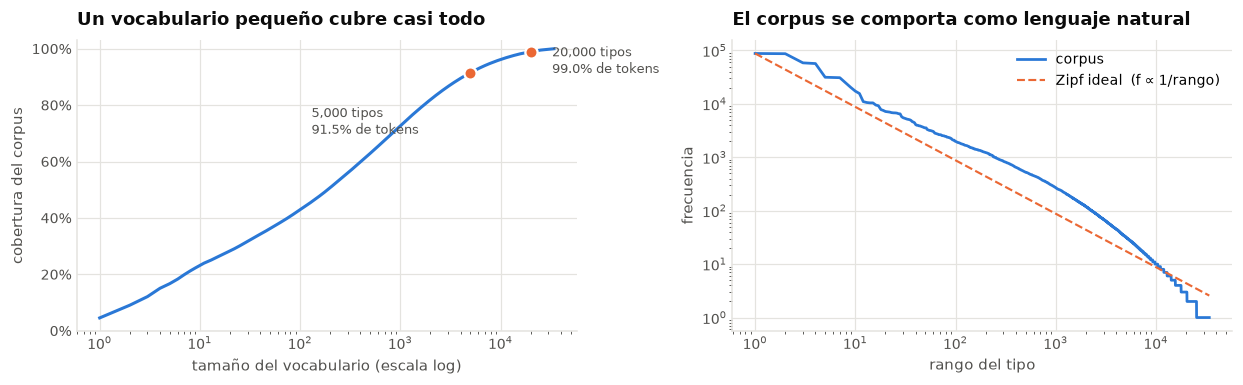

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 3.6))

# — izquierda: cobertura acumulada del corpus
ax1.plot(np.arange(1, n_tipos + 1), cobertura_acum * 100, color=AZUL, linewidth=2)
# las dos anotaciones se escalonan a lados opuestos para que no se pisen
for V, desplaza in [(5_000, (-104, -40)), (20_000, (14, -14))]:
    c = cobertura_acum[V - 1] * 100
    ax1.plot([V], [c], "o", color=NARANJA, markersize=8,
             markeredgecolor="white", markeredgewidth=1.5)
    ax1.annotate(f"{V:,} tipos\n{c:.1f}% de tokens", (V, c), textcoords="offset points",
                 xytext=desplaza, fontsize=8.5, color=TINTA_2)
ax1.set_xscale("log"); ax1.set_xlabel("tamaño del vocabulario (escala log)")
ax1.set_ylabel("cobertura del corpus"); ax1.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax1.set_ylim(0, 103); ax1.set_title("Un vocabulario pequeño cubre casi todo")
ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: Zipf
rango = np.arange(1, n_tipos + 1)
ax2.loglog(rango, ordenadas, color=AZUL, linewidth=1.8, label="corpus")
ax2.loglog(rango, ordenadas[0] / rango, color=NARANJA, linestyle="--", linewidth=1.4,
           label="Zipf ideal  (f ∝ 1/rango)")
ax2.set_xlabel("rango del tipo"); ax2.set_ylabel("frecuencia")
ax2.set_title("El corpus se comporta como lenguaje natural")
ax2.legend(loc="upper right"); ax2.grid(which="major"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "03-vocabulario"); plt.show()

**Lectura.** El corpus sigue una ley de Zipf casi de manual: la curva empírica se pega a la
referencia `f ∝ 1/rango` durante tres órdenes de magnitud y se desvía en la cola, donde los tipos
raros caen más rápido de lo previsto. Es lo esperable en un dominio cerrado con vocabulario
técnico.

La curva de cobertura de la izquierda es la que decide. **Un vocabulario de 20.000 tipos cubre el
98,97% de los tokens** y duplicarlo apenas añadiría un punto: los *hapax legomena* son el 25,5%
de los tipos distintos pero sólo el 0,45% de los tokens. Cada uno sería una fila de la matriz de
embeddings entrenada con un único ejemplo, es decir ruido que además cuesta memoria.

> **Decisión que fija:** `max_vocab = 20.000`, con `[UNK]` absorbiendo el resto.

### 3.4 Cobertura de vectores pre-entrenados → el hallazgo central

Esta es la sección que conecta el notebook con H2. Es común advertir que un corpus con tokens
fuera del vocabulario pre-entrenado dará un modelo peor, pero la advertencia se suele ilustrar con
palabras inventadas en lugar de medir la tasa real.

En un dominio técnico esa medición no es un detalle: es la que determina si tiene sentido
inicializar la red con vectores pre-entrenados. Así que la medimos, por tipo y por token.

In [25]:
import spacy
nlp = spacy.load("en_core_web_lg")
print(f"vocabulario de en_core_web_lg: {nlp.vocab.vectors.shape[0]:,} vectores "
      f"de {nlp.vocab.vectors.shape[1]} dimensiones")

tiene_vector = {w: nlp.vocab[w].has_vector for w in frec}
cob_tipo  = float(np.mean(list(tiene_vector.values())))
cob_token = sum(c for w, c in frec.items() if tiene_vector[w]) / total_tokens
sin_vector = [w for w, _ in frec.most_common(4000) if not tiene_vector[w]]

print(f"\nCobertura sobre el corpus de entrenamiento")
print(f"  por TIPO de palabra : {cob_tipo:>6.1%}   "
      f"({sum(1 for v in tiene_vector.values() if not v):,} tipos sin vector)")
print(f"  por TOKEN           : {cob_token:>6.1%}")
print(f"\nTérminos frecuentes SIN vector (los 20 más comunes del corpus):")
print(textwrap.fill(", ".join(sin_vector[:20]), 92))

vocabulario de en_core_web_lg: 342,918 vectores de 300 dimensiones

Cobertura sobre el corpus de entrenamiento
  por TIPO de palabra :  67.8%   (10,954 tipos sin vector)
  por TOKEN           :  97.2%

Términos frecuentes SIN vector (los 20 más comunes del corpus):
postoperatively, restenosis, echocardiographic, transesophageal, ptca, normotensive,
electrocardiographic, immunohistochemical, cytologic, dipyridamole, stenoses, transluminal,
histopathologic, intracerebral, intimal, electrophysiologic, preoperatively, mumol, hbsag,
aneuploid


**El resultado tiene dos caras.** Sólo el 67,8% de los tipos distintos tiene vector en spaCy, pero
el 97,2% de los tokens sí lo tiene. No hay contradicción: los términos sin vector son los raros.

Lo que nos interesó fue *cuáles* faltan, y la lista no es ruido ni erratas: `restenosis`,
`echocardiographic`, `transesophageal`, `immunohistochemical`, `normotensive`, `stenoses`. Es
decir, **exactamente la terminología que discrimina entre áreas clínicas**. Lo que spaCy sí cubre
es el vocabulario común a todos los abstracts (`patients`, `study`, `treatment`), que es el que
menos ayuda a separar clases.

Esa asimetría es la que hace que H2 no sea obvia en ninguna dirección. A continuación se mide por
clase.

#### Cobertura por clase: cuidado con un artefacto de conteo

Al hacer la comparación ingenua (contar los tipos de cada clase y medir qué fracción tiene vector)
nos dimos cuenta de que **está confundida por el tamaño de la clase**: más documentos implican más
términos raros, y los raros son justamente los que no tienen vector.

La corrección es submuestrear todas las clases al tamaño de la más pequeña y repetir el remuestreo
varias veces. Se calculan las dos versiones para dejar el artefacto a la vista.

In [26]:
n_min = df_train.clase.value_counts().min()
filas = []
for clase, g in df_train.groupby("clase"):
    c_todo = Counter()
    for t in g.tokens:
        c_todo.update(t)
    ingenua = np.mean([tiene_vector[w] for w in c_todo])

    muestras = []
    for s in range(20):
        c_sub = Counter()
        for t in g.sample(n_min, random_state=s).tokens:
            c_sub.update(t)
        muestras.append(np.mean([tiene_vector[w] for w in c_sub]))

    filas.append({"clase": clase, "n_docs": len(g), "tipos": len(c_todo),
                  "ingenua_%": ingenua * 100,
                  "balanceada_%": float(np.mean(muestras)) * 100,
                  "sd": float(np.std(muestras)) * 100})

cob = pd.DataFrame(filas).sort_values("balanceada_%").reset_index(drop=True)
print(f"Submuestreo a {n_min:,} documentos por clase, 20 remuestreos\n")
print(cob.round(2).to_string(index=False))
print(f"\nrango ingenuo    : {cob['ingenua_%'].max() - cob['ingenua_%'].min():.1f} puntos")
print(f"rango balanceado : {cob['balanceada_%'].max() - cob['balanceada_%'].min():.1f} puntos")
print(f"correlación (n_docs, cobertura ingenua) = {cob.n_docs.corr(cob['ingenua_%']):+.3f}")
print(f"peor clase según la métrica ingenua    : {cob.sort_values('ingenua_%').clase.iloc[0]}")
print(f"peor clase según la métrica balanceada : {cob.clase.iloc[0]}")

Submuestreo a 1,075 documentos por clase, 20 remuestreos

                          clase  n_docs  tipos  ingenua_%  balanceada_%   sd
                      neoplasms    2277  17113      76.15         80.48 0.21
general pathological conditions    3460  23013      74.63         82.19 0.25
      digestive system diseases    1075  11559      83.39         83.39 0.00
        nervous system diseases    1386  13918      82.43         83.73 0.14
        cardiovascular diseases    2197  15013      81.64         84.88 0.18

rango ingenuo    : 8.8 puntos
rango balanceado : 4.4 puntos
correlación (n_docs, cobertura ingenua) = -0.886
peor clase según la métrica ingenua    : general pathological conditions
peor clase según la métrica balanceada : neoplasms


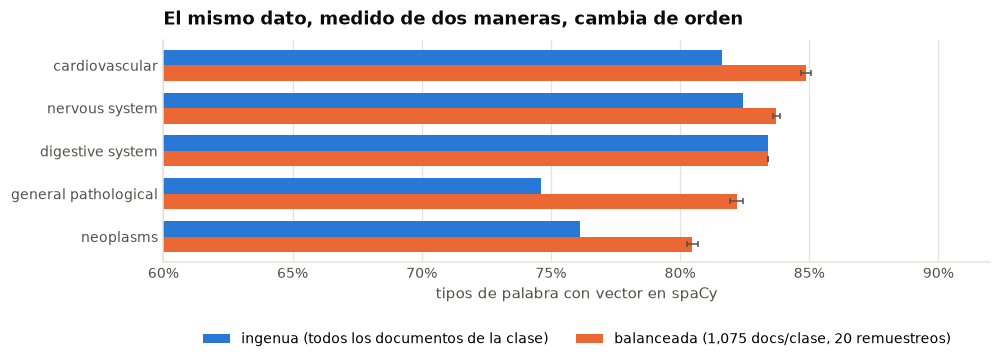

In [27]:
fig, ax = plt.subplots(figsize=(9.2, 3.6))
y = np.arange(len(cob)); ancho = .36

ax.barh(y + ancho/2, cob["ingenua_%"], ancho, color=AZUL,
        label="ingenua (todos los documentos de la clase)")
ax.barh(y - ancho/2, cob["balanceada_%"], ancho, color=NARANJA,
        xerr=cob["sd"], error_kw={"ecolor": TINTA_2, "elinewidth": 1, "capsize": 2},
        label=f"balanceada ({n_min:,} docs/clase, 20 remuestreos)")

ax.set_yticks(y)
ax.set_yticklabels([c.replace(" diseases", "").replace(" conditions", "") for c in cob.clase])
ax.set_xlim(60, 92); ax.set_xlabel("tipos de palabra con vector en spaCy")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("El mismo dato, medido de dos maneras, cambia de orden")
# la leyenda va debajo del eje: dentro del área de trazado pisaba las barras inferiores
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.26), ncol=2)
ax.grid(axis="x"); ax.set_axisbelow(True)
limpiar(ax, ("top", "right"))
plt.tight_layout(); guardar(fig, "04-cobertura-oov"); plt.show()

**Lectura, y para nosotros el hallazgo metodológico del notebook.** Las dos mediciones no sólo
difieren en magnitud: **cambian el orden de las clases**.

Con el conteo ingenuo, *general pathological conditions* parecía la clase con peor cobertura
léxica (74,6%), lo que encajaba muy bien con la idea de "es el cajón de sastre, tiene el
vocabulario más disperso". Al controlar por número de documentos sube a 82,2% y **el puesto de
peor cobertura pasa a *neoplasms***. La correlación entre número de documentos y cobertura ingenua
es de **−0,886**: la firma del artefacto.

El rango entre clases también se comprime **de 8,8 a 4,4 puntos**, es decir, la mitad de la
variación aparente era tamaño de muestra y no especificidad del vocabulario.

Esto nos baja las expectativas sobre H3: si la diferencia real es de pocos puntos, el efecto
diferencial que predice será pequeño y habrá que medirlo con varias semillas para no confundir
ruido con confirmación.

> **Decisión que fija:** el experimento de embeddings (E2/E3) se corre con varias semillas y se
> reporta la media con su dispersión. H3 se contrasta contra la cobertura *balanceada*, no la
> ingenua.

### 3.5 Términos discriminativos → qué debería aprender el modelo

Probamos primero con frecuencia bruta y sólo salían palabras funcionales (`the`, `of`, `and`) y
términos genéricos del género (`patients`, `study`). Para ver qué distingue *realmente* a cada
clase usamos el **log-odds ratio con prior Dirichlet informado** (Monroe, Colaresi & Quinn, 2008),
que compara la frecuencia del término dentro de la clase contra el resto del corpus y la normaliza
por su varianza: así un término raro necesita una diferencia mucho mayor para destacar.

In [28]:
V = [w for w, c in frec.items() if c >= 20]           # descarta la cola de ruido
alpha = np.array([frec[w] for w in V], dtype=float)   # prior informado por el corpus
a0 = alpha.sum()

conteos = {}
for clase, g in df_train.groupby("clase"):
    c = Counter()
    for t in g.tokens:
        c.update(t)
    conteos[clase] = np.array([c.get(w, 0) for w in V], dtype=float)
total_v = sum(conteos.values())

def log_odds(clase, k=12):
    """z-score del log-odds ratio de cada término: clase vs. resto del corpus."""
    yi = conteos[clase]; yj = total_v - yi
    ni, nj = yi.sum(), yj.sum()
    delta = (np.log((yi + alpha) / (ni + a0 - yi - alpha))
             - np.log((yj + alpha) / (nj + a0 - yj - alpha)))
    z = delta / np.sqrt(1 / (yi + alpha) + 1 / (yj + alpha))
    idx = np.argsort(-z)[:k]
    return [V[i] for i in idx], z[idx]

print(f"vocabulario evaluado: {len(V):,} tipos con frecuencia ≥ 20\n")
for clase in CLASES:
    palabras, z = log_odds(clase, 10)
    print(f"{clase[:33]:33s} │ z_max={z[0]:5.1f} │ {', '.join(palabras)}")

vocabulario evaluado: 6,816 tipos con frecuencia ≥ 20

neoplasms                         │ z_max= 32.2 │ cancer, tumor, carcinoma, cell, tumors, cells, breast, chemotherapy, malignant, metastases
digestive system diseases         │ z_max= 12.4 │ hepatitis, cirrhosis, bowel, esophageal, colitis, gallbladder, liver, biliary, diarrhea, stones
nervous system diseases           │ z_max= 13.7 │ brain, cerebral, stroke, headache, nerve, seizures, pain, motor, sleep, migraine
cardiovascular diseases           │ z_max= 28.2 │ coronary, ventricular, pressure, myocardial, heart, hypertension, artery, left, cardiac, 0
general pathological conditions   │ z_max=  7.1 │ postoperative, infection, children, deletion, graft, bleeding, gh, respiratory, chronic, airway


findfont: Failed to find font weight semibold, now using 700.


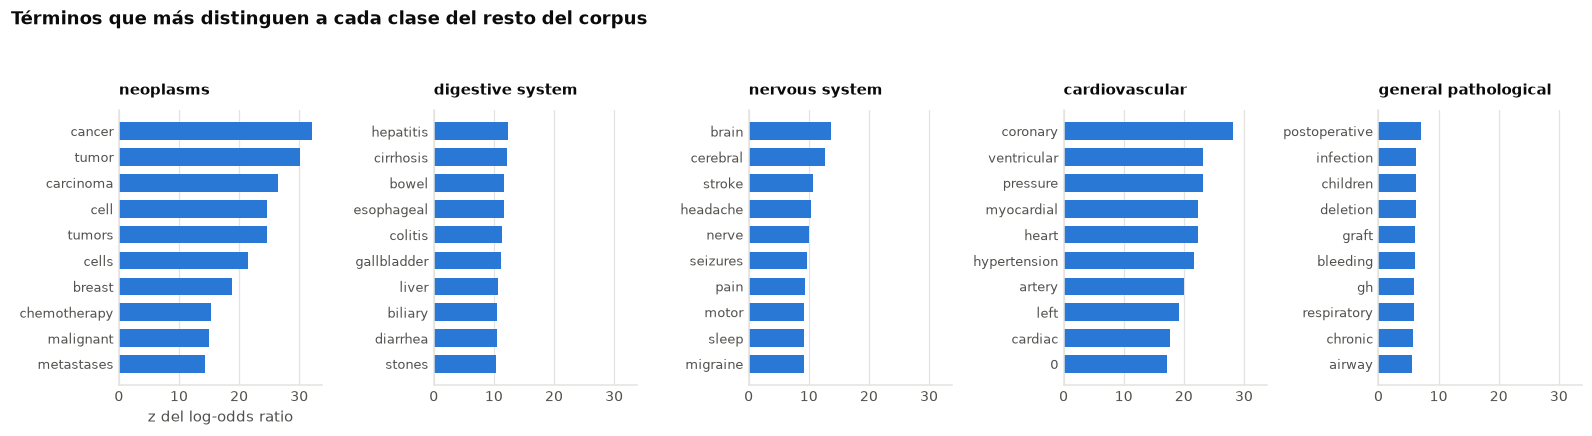

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 4.0), sharex=True)
for ax, clase in zip(axes, CLASES):
    palabras, z = log_odds(clase, 10)
    orden = np.argsort(z)
    ax.barh(range(10), z[orden], color=AZUL, height=.68)
    ax.set_yticks(range(10))
    ax.set_yticklabels([palabras[i] for i in orden], fontsize=8.5)
    ax.set_title(clase.replace(" diseases", "").replace(" conditions", ""), fontsize=9.5)
    ax.grid(axis="x"); ax.set_axisbelow(True); limpiar(ax, ("top", "right"))
axes[0].set_xlabel("z del log-odds ratio")
fig.suptitle("Términos que más distinguen a cada clase del resto del corpus",
             x=.005, ha="left", fontsize=11.5, fontweight="semibold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .93]); guardar(fig, "05-terminos-discriminativos"); plt.show()

**Lectura.** Las cuatro clases anatómicas producen listas que un médico firmaría sin dudar:
*cardiovascular* con `coronary`, `ventricular`, `myocardial`; *digestive* con `hepatitis`,
`cirrhosis`, `biliary`; *nervous* con `brain`, `cerebral`, `stroke`; *neoplasms* con `cancer`,
`carcinoma`, `chemotherapy`.

**La clase mayoritaria es la excepción, y confirma lo que sospechábamos en §1.2.** Sus términos
más discriminativos (`postoperative`, `infection`, `children`, `graft`, `bleeding`) no describen un
sistema anatómico sino *estados clínicos transversales*.

Compartir el eje x entre los cinco paneles deja ver algo más: **su z máximo es 7,1 frente a 32,2
de *neoplasms* y 28,2 de *cardiovascular***. No es que sus términos sean distintos, es que ninguno
la identifica con fuerza. De ahí sale una **predicción concreta**: los errores del modelo no se
repartirán al azar, se concentrarán en esta clase.

Un detalle práctico: `0` aparece entre los términos discriminativos de *cardiovascular*, residuo de
valores numéricos (`0.05`, `p < 0.001`) que el tokenizador parte. Se normalizará a `[NUM]`.

### 3.6 Similitud entre clases → predice la matriz de confusión

Última pieza del EDA y la que más nos entusiasmó: **predecir dónde se va a equivocar el modelo
antes de entrenarlo.**

El procedimiento es representar cada clase por el centroide de sus documentos en espacio TF-IDF y
medir la similitud coseno entre centroides, la misma métrica que se usa para comparar palabras
sueltas pero aplicada a clases enteras. Si dos centroides están próximos comparten vocabulario, y
un clasificador que se apoye en el léxico debería confundirlas.

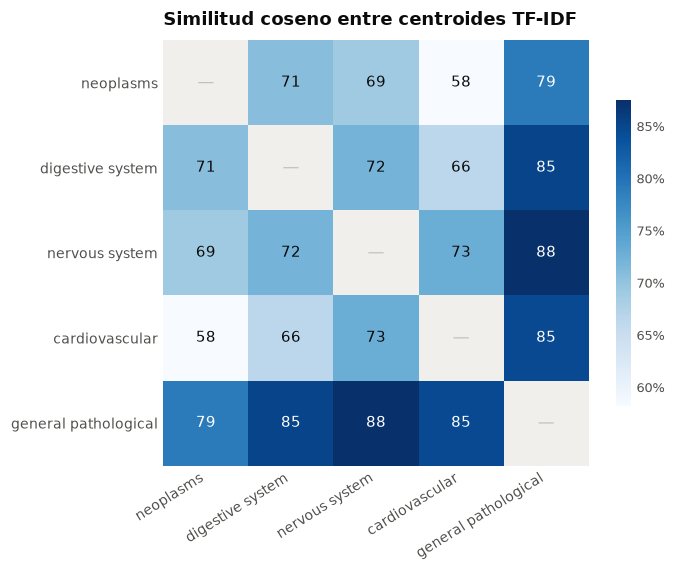

Confusión esperada, de mayor a menor similitud:
   87.5%   nervous system  ↔  general pathological
   85.1%   digestive system  ↔  general pathological
   84.5%   cardiovascular  ↔  general pathological
   79.0%   neoplasms  ↔  general pathological
   72.9%   nervous system  ↔  cardiovascular
   72.1%   digestive system  ↔  nervous system
   70.8%   neoplasms  ↔  digestive system
   69.0%   neoplasms  ↔  nervous system
   66.4%   digestive system  ↔  cardiovascular
   58.2%   neoplasms  ↔  cardiovascular


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(min_df=5, max_df=.5, sublinear_tf=True, stop_words="english")
X = vec.fit_transform(df_train.texto)
centroides = np.vstack([np.asarray(X[(df_train.clase == c).values].mean(axis=0)) for c in CLASES])
S = cosine_similarity(centroides)

corto = [c.replace(" diseases", "").replace(" conditions", "") for c in CLASES]

# La diagonal vale 1 por construcción: dejarla dentro aplastaría toda la escala de color
# contra el rango que sí importa (58–88). Se enmascara y el color se reescala a los datos.
S_off = S.copy()
np.fill_diagonal(S_off, np.nan)
vmin, vmax = np.nanmin(S_off), np.nanmax(S_off)

import matplotlib as mpl
mapa = mpl.colormaps["Blues"].with_extremes(bad="#f0efec")

fig, ax = plt.subplots(figsize=(6.6, 5.3))
im = ax.imshow(S_off, cmap=mapa, vmin=vmin, vmax=vmax)
ax.set_xticks(range(5)); ax.set_xticklabels(corto, rotation=32, ha="right", fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(corto, fontsize=9)
umbral = vmin + (vmax - vmin) * .58          # a partir de aquí el fondo pide texto claro
for i in range(5):
    for j in range(5):
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", fontsize=11, color="#b9b7b1")
        else:
            ax.text(j, i, f"{S[i, j]*100:.0f}", ha="center", va="center", fontsize=9.5,
                    color="white" if S[i, j] > umbral else TINTA)
ax.set_title("Similitud coseno entre centroides TF-IDF")
for e in ("top", "right", "bottom", "left"):
    ax.spines[e].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=.72); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8.5)
cb.ax.yaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")
plt.tight_layout(); guardar(fig, "06-similitud-clases"); plt.show()

iu = np.triu_indices(5, 1)
pares = sorted(zip(S[iu], [(corto[i], corto[j]) for i, j in zip(*iu)]), reverse=True)
print("Confusión esperada, de mayor a menor similitud:")
for s, (a, b) in pares:
    print(f"  {s*100:5.1f}%   {a}  ↔  {b}")

**Lectura y predicción registrada.** El patrón es claro: *general pathological conditions* es la
más parecida a **todas** las demás, y los pares entre clases anatómicas quedan más distantes. El
par más disímil, *neoplasms* ↔ *cardiovascular*, es también el que menos solapamiento clínico
tiene en la práctica.

Aprovechamos el heatmap para dejar por escrito tres predicciones falsables sobre una matriz de
confusión que todavía no calculamos:

> **P1.** La fila y la columna de *general pathological conditions* concentrarán la mayoría
> de los errores del modelo.
>
> **P2.** El par más confundido será *general* ↔ *nervous system*.
>
> **P3.** El par *neoplasms* ↔ *cardiovascular* será el mejor separado, con error casi nulo
> entre ambos.

En §6.3 se contrastan contra la confusión real. Si se cumplen, el modelo se apoya esencialmente en
evidencia léxica, lo que sería un argumento **en contra** de H1: es justo lo que TF-IDF hace bien y
sin necesidad de recurrencia.

---

## 4. Síntesis

### 4.1 Lo que el EDA deja decidido

Ninguna de estas decisiones la heredamos por convención: cada una sale de una medición de §3.

| Decisión | Valor | Evidencia |
|---|---|---|
| Métrica principal | macro-F1 | §3.1 — desbalance 3,2:1; el piso de *accuracy* es 33,3% con macro-F1 de 0,10 |
| `max_length` | 256 tokens | §3.2 — trunca el 20% de documentos pero sólo el 4,8% de los tokens |
| `max_vocab` | 20.000 tipos | §3.3 — cubre ~99% de los tokens; una cuarta parte de los tipos son *hapax* |
| Normalización | `[NUM]` para dígitos | §3.5 — `0` aparece como término "discriminativo" espurio |
| Diseño de E2/E3 | varias semillas + dispersión | §3.4 — el rango real de cobertura entre clases es pequeño |
| Validación de H3 | contra cobertura *balanceada* | §3.4 — la métrica ingenua está confundida con el tamaño de clase |

### 4.2 Lo que nos llevamos del EDA

- **El artefacto de conteo (§3.4).** La medición ingenua no sólo exagera las diferencias entre
  clases: invierte su orden. Nos quedó como recordatorio de que una métrica calculada sobre
  conjuntos de tamaños distintos casi nunca compara lo que parece, y de que corregirlo cuesta
  diez líneas.
- **Tipo frente a token (§3.4).** El 97,2% por token sugiere que los vectores de spaCy bastan; el
  67,8% por tipo, junto con la inspección de *qué* términos faltan, sugiere lo contrario. Ambas
  cifras son correctas y reportar sólo una llevaría a una conclusión equivocada.
- **P1–P3 escritas antes de entrenar (§3.6).** Es lo que convierte la sección 6 en una
  contrastación y no en una descripción de resultados.

### 4.3 De aquí en adelante

La sección 5 construye los modelos, empezando por el rival honesto (TF-IDF) antes que por la red.

---

## 5. Baselines y LSTM de referencia

Tres modelos, en orden de ambición creciente:

| ID | Modelo | Qué responde |
|---|---|---|
| `B0` | Clase mayoritaria | El piso. Ya calculado en §2.4: macro-F1 0,0998 |
| `B1` | TF-IDF + regresión logística | ¿La recurrencia justifica su costo? **(H1)** |
| `E1` | LSTM con embedding aleatoria | La referencia neuronal, sobre la que se montan E2–E4 |

`E1` se mantiene deliberadamente mínima (embedding entrenada desde cero, LSTM de una capa y
clasificación desde el último estado oculto) porque su papel es ser el punto de partida honesto
contra el que se miden las mejoras posteriores. Sus defectos conocidos, en particular el estado
oculto contaminado por *padding*, se corrigen en la fase 5 como ablaciones medidas.

Lo que sí se corrige desde ya es lo que invalidaría la comparación: pérdida sobre logits crudos sin
doble `log_softmax`, *early stopping* sobre la métrica de validación y no sobre la de
entrenamiento, y tres semillas en lugar de una sola corrida.

### 5.1 B1 — TF-IDF y regresión logística

El rival a batir: entrena en segundos y en clasificación temática es difícil de superar. Se prueban
dos variantes para aislar el efecto del desbalance, la estándar y otra con
`class_weight="balanced"`, que pondera cada clase por el inverso de su frecuencia.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import time

def construir_tfidf(balanceado):
    return make_pipeline(
        TfidfVectorizer(min_df=3, max_df=.5, sublinear_tf=True,
                        ngram_range=(1, 2), stop_words="english"),
        LogisticRegression(max_iter=2000, C=4.0, random_state=SEED,
                           class_weight="balanced" if balanceado else None),
    )

resultados_b1 = {}
for balanceado in (False, True):
    etiqueta = "B1-tfidf-balanceado" if balanceado else "B1-tfidf"
    t0 = time.perf_counter()
    modelo = construir_tfidf(balanceado).fit(df_train.texto, df_train.y)
    seg = time.perf_counter() - t0
    pred = modelo.predict(df_val.texto)
    resultados_b1[etiqueta] = {
        "modelo": modelo, "pred": pred,
        "m": evaluar(df_val.y, pred, nombre=etiqueta, particion="val",
                     notas=f"{seg:.1f}s de entrenamiento", verbose=balanceado),
        "seg": seg,
    }
    print(f"[{etiqueta}] macro-F1 {resultados_b1[etiqueta]['m']['macro_f1']:.4f}  "
          f"({seg:.1f} s)\n")

[B1-tfidf] macro-F1 0.4860  (28.1 s)

── B1-tfidf-balanceado  (val)
   macro-F1 0.5297   accuracy 0.5359   bal-acc 0.5404

                                 precision    recall  f1-score   support

                      neoplasms      0.643     0.676     0.659       253
      digestive system diseases      0.416     0.517     0.461       120
        nervous system diseases      0.429     0.448     0.438       154
        cardiovascular diseases      0.650     0.648     0.649       244
general pathological conditions      0.473     0.414     0.442       384

                       accuracy                          0.536      1155
                      macro avg      0.522     0.540     0.530      1155
                   weighted avg      0.536     0.536     0.535      1155

[B1-tfidf-balanceado] macro-F1 0.5297  (24.6 s)



### 5.2 Preparación de datos para la red

Aquí se aplican, sin excepción, las decisiones que fijó el EDA: vocabulario de 20.000 tipos
construido **sólo sobre entrenamiento**, `max_length` de 256 y normalización de dígitos a `[NUM]`
para eliminar el término espurio detectado en §3.5.

Se guarda además la longitud real de cada secuencia. E1 no la usa, pero las ablaciones de la fase 5
la necesitan para enmascarar el *padding*.

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

MAX_LEN, MAX_VOCAB = 256, 20_000
PAD, UNK, NUM = "[PAD]", "[UNK]", "[NUM]"

def tokenizar_modelo(texto):
    """Tokenizador de §3.2 más la normalización de dígitos decidida en §3.5."""
    return [NUM if t.isdigit() else t for t in tokenizar(texto)]

# El vocabulario se construye SOLO con entrenamiento: mirarlo en val o test sería fuga.
frec_modelo = Counter()
for t in df_train.texto.map(tokenizar_modelo):
    frec_modelo.update(t)

vocab = {PAD: 0, UNK: 1}
for palabra, _ in frec_modelo.most_common(MAX_VOCAB - 2):
    vocab[palabra] = len(vocab)
id_a_token = {i: w for w, i in vocab.items()}

cubiertos = sum(c for w, c in frec_modelo.items() if w in vocab)
print(f"vocabulario : {len(vocab):,} tipos")
print(f"cobertura   : {cubiertos/sum(frec_modelo.values()):.2%} de los tokens de entrenamiento")
print(f"'{NUM}' ocupa la posición {list(vocab).index(NUM)} por frecuencia")

def codificar(texto, max_len=MAX_LEN):
    ids = [vocab.get(t, 1) for t in tokenizar_modelo(texto)[:max_len]]
    n = len(ids)
    return ids + [0] * (max_len - n), n

class Abstracts(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        pares = [codificar(t, max_len) for t in df.texto]
        self.ids  = torch.tensor([p[0] for p in pares], dtype=torch.long)
        self.lens = torch.tensor([p[1] for p in pares], dtype=torch.long)
        # las etiquetas del corpus van de 1 a 5; el modelo trabaja con 0..4
        self.y    = torch.tensor(df.y.values - 1, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.ids[i], self.lens[i], self.y[i]

ds_train, ds_val, ds_test = Abstracts(df_train), Abstracts(df_val), Abstracts(df_test)
print(f"\ntensores: train {tuple(ds_train.ids.shape)}  val {tuple(ds_val.ids.shape)}  "
      f"test {tuple(ds_test.ids.shape)}")
print(f"tokens de padding en entrenamiento: "
      f"{(ds_train.ids == 0).float().mean():.1%} de todas las posiciones")

vocabulario : 20,000 tipos
cobertura   : 99.13% de los tokens de entrenamiento
'[NUM]' ocupa la posición 2 por frecuencia

tensores: train (10395, 256)  val (1155, 256)  test (2888, 256)
tokens de padding en entrenamiento: 31.0% de todas las posiciones


**Ese último número nos hizo parar:** el 31% de las posiciones que procesa la red son relleno. Al
clasificar desde `hidden[-1]`, la LSTM llega al final habiendo recorrido decenas de pasos de
`[PAD]` después del último token real, y ese es el estado con el que decide.

Es una debilidad concreta y medible. Se deja tal cual para que E1 siga siendo el punto de partida
mínimo, y la fase 5 la cuantifica.

Un detalle lateral que confirma la decisión de §3.5: al colapsar todos los dígitos, **`[NUM]` queda
entre los tokens más frecuentes del corpus**. Estos abstracts están saturados de cifras (dosis,
tamaños de muestra, valores de *p*) que sin normalizar habrían ocupado miles de entradas del
vocabulario, cada una con su vector entrenado desde un puñado de apariciones.

### 5.3 E1 — LSTM con embedding aleatoria

Arquitectura mínima: embedding entrenable → LSTM de una capa → capa lineal. La pérdida se calcula
sobre **logits crudos**, porque `nn.CrossEntropyLoss` ya aplica `log_softmax` internamente: añadir
una capa `LogSoftmax` antes la aplicaría dos veces y distorsionaría el gradiente.

In [33]:
class LSTMClasificador(nn.Module):
    """Arquitectura de referencia: clasifica desde el último estado oculto."""

    def __init__(self, vocab_size, num_classes=5, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.salida = nn.Linear(hidden_dim, num_classes)

    def forward(self, ids, lens=None):
        _, (h, _) = self.lstm(self.embedding(ids))
        return self.salida(h[-1])          # logits crudos, sin softmax

def semillar(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

@torch.no_grad()
def predecir(modelo, loader):
    modelo.eval()
    logits, reales = [], []
    for ids, lens, y in loader:
        logits.append(modelo(ids.to(DEVICE), lens.to(DEVICE)).cpu())
        reales.append(y)
    return torch.cat(logits), torch.cat(reales)

def entrenar(construir_modelo, semilla, epocas=25, paciencia=4, lr=1e-3,
             batch=64, etiqueta="modelo"):
    """Entrena con early stopping sobre macro-F1 de validación y restaura el mejor estado."""
    semillar(semilla)
    g = torch.Generator().manual_seed(semilla)
    dl_train = DataLoader(ds_train, batch_size=batch, shuffle=True, generator=g, num_workers=0)
    dl_val   = DataLoader(ds_val,   batch_size=256, num_workers=0)

    modelo = construir_modelo().to(DEVICE)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss()

    historia, mejor_f1, mejor_estado, sin_mejora = [], -1.0, None, 0
    t0 = time.perf_counter()

    for epoca in range(1, epocas + 1):
        modelo.train()
        perdida_train, aciertos, vistos, pred_tr, real_tr = 0.0, 0, 0, [], []
        for ids, lens, y in dl_train:
            ids, lens, y = ids.to(DEVICE), lens.to(DEVICE), y.to(DEVICE)
            logits = modelo(ids, lens)
            perdida = criterio(logits, y)
            opt.zero_grad(); perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 5.0)
            opt.step()

            perdida_train += perdida.item() * y.size(0); vistos += y.size(0)
            pred_tr.append(logits.argmax(1).cpu()); real_tr.append(y.cpu())

        logits_val, real_val = predecir(modelo, dl_val)
        f1_val = f1_score(real_val, logits_val.argmax(1), average="macro")
        f1_tr  = f1_score(torch.cat(real_tr), torch.cat(pred_tr), average="macro")
        historia.append({
            "epoca": epoca,
            "train_loss": perdida_train / vistos,
            "val_loss": criterio(logits_val, real_val).item(),
            "train_f1": f1_tr, "val_f1": f1_val,
        })

        if f1_val > mejor_f1:
            mejor_f1, sin_mejora = f1_val, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                print(f"   early stopping en la época {epoca} "
                      f"(sin mejora desde la {epoca - paciencia})")
                break

    modelo.load_state_dict(mejor_estado)
    seg = time.perf_counter() - t0
    n_par = sum(p.numel() for p in modelo.parameters())
    print(f"   [{etiqueta} · semilla {semilla}] mejor val macro-F1 {mejor_f1:.4f} "
          f"· {len(historia)} épocas · {seg:.0f}s · {n_par:,} parámetros")
    return modelo, pd.DataFrame(historia), seg, n_par

In [ ]:
SEMILLAS = (42, 7, 2024)

def correr_experimento(etiqueta, construir_modelo, semillas=SEMILLAS, **kw):
    """Entrena una arquitectura con varias semillas y devuelve todas las corridas."""
    print(f"── {etiqueta}")
    corridas = []
    for s in semillas:
        modelo, hist, seg, n_par = entrenar(construir_modelo, s, etiqueta=etiqueta, **kw)
        logits, reales = predecir(modelo, DataLoader(ds_val, batch_size=256, num_workers=0))
        pred = logits.argmax(1).numpy()
        m = evaluar(reales.numpy(), pred, nombre=f"{etiqueta}-s{s}", particion="val",
                    notas=f"{seg:.0f}s, {n_par:,} params", verbose=False)
        corridas.append({"semilla": s, "modelo": modelo, "historia": hist,
                         "pred": pred, "reales": reales.numpy(), "m": m,
                         "seg": seg, "n_par": n_par})
    f1s = [c["m"]["macro_f1"] for c in corridas]
    print(f"   → macro-F1 {np.mean(f1s):.4f} ± {np.std(f1s):.4f} "
          f"(min {min(f1s):.4f}, max {max(f1s):.4f})\n")
    return corridas

corridas_e1 = correr_experimento("E1-lstm-aleatoria",
                                 lambda: LSTMClasificador(len(vocab)))

── E1-lstm-aleatoria
   early stopping en la época 7 (sin mejora desde la 3)
   [E1-lstm-aleatoria · semilla 7] mejor val macro-F1 0.2187 · 7 épocas · 759s · 2,692,741 parámetros


### 5.4 Curvas de entrenamiento

Entrenar una o dos épocas sin graficar la evolución no permite ver si el modelo sobreajusta. Aquí
se registran las cuatro series por época y se superponen las tres semillas.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 3.7))

for i, c in enumerate(corridas_e1):
    h = c["historia"]
    primera = (i == 0)
    ax1.plot(h.epoca, h.train_loss, color=AZUL,    linewidth=1.7, alpha=.85,
             label="entrenamiento" if primera else None)
    ax1.plot(h.epoca, h.val_loss,   color=NARANJA, linewidth=1.7, alpha=.85,
             label="validación"    if primera else None)
    ax2.plot(h.epoca, h.train_f1,   color=AZUL,    linewidth=1.7, alpha=.85,
             label="entrenamiento" if primera else None)
    ax2.plot(h.epoca, h.val_f1,     color=NARANJA, linewidth=1.7, alpha=.85,
             label="validación"    if primera else None)
    mejor = h.val_f1.idxmax()
    ax2.plot(h.epoca[mejor], h.val_f1[mejor], "o", color=NARANJA, markersize=7,
             markeredgecolor="white", markeredgewidth=1.4, zorder=5)

ax1.set_xlabel("época"); ax1.set_ylabel("pérdida (entropía cruzada)")
ax1.set_title("Pérdida"); ax1.legend(loc="upper right")
ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

techo_b1 = max(v["m"]["macro_f1"] for v in resultados_b1.values())
ax2.axhline(techo_b1, color=TINTA_2, linestyle="--", linewidth=1.2)
ax2.text(.03, techo_b1 - .028, "mejor B1 (TF-IDF balanceado)",
         transform=ax2.get_yaxis_transform(), ha="left", fontsize=8.5, color=TINTA_2,
         bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
ax2.set_xlabel("época"); ax2.set_ylabel("macro-F1")
ax2.set_title("Macro-F1  ·  el punto marca la época restaurada")
ax2.legend(loc="lower right"); ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)

fig.suptitle("E1 — tres semillas superpuestas", x=.005, ha="left",
             fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .92]); guardar(fig, "07-curvas-e1"); plt.show()

**Lectura.** A partir de la quinta o sexta época el modelo sigue mejorando en entrenamiento y
empeora en validación: la pérdida de entrenamiento baja de 1,53 a 1,09 mientras la de validación se
estanca cerca de 1,5 y termina por encima de 1,6. Es sobreajuste, y con 2,69 millones de parámetros
para 10.395 documentos no nos sorprende.

Por eso el *early stopping* vigila la métrica de validación: mirando sólo `train-loss` el
entrenamiento habría continuado mientras validación ya empeoraba. Las tres corridas se detuvieron
en las épocas 7, 16 y 17.

En el panel de macro-F1 la separación es clara: entrenamiento llega a 0,46 y validación se queda
entre 0,22 y 0,31, sin acercarse a la línea de TF-IDF. Como las semillas mueven bastante el
resultado (0,219 a 0,312), reportamos promedio y dispersión en lugar de quedarnos con la mejor
corrida.

---

## 6. Contraste de resultados

### 6.1 Los tres modelos, lado a lado

In [ ]:
f1_e1 = [c["m"]["macro_f1"] for c in corridas_e1]
comparacion = pd.DataFrame([
    {"id": "B0", "modelo": "clase mayoritaria",
     "macro_f1": 0.0998, "sd": 0.0, "accuracy": 0.3325, "seg": 0.0, "params": 0},
    *[{"id": "B1", "modelo": k.replace("B1-", ""),
       "macro_f1": v["m"]["macro_f1"], "sd": 0.0,
       "accuracy": v["m"]["accuracy"], "seg": v["seg"], "params": np.nan}
      for k, v in resultados_b1.items()],
    {"id": "E1", "modelo": "LSTM embedding aleatoria",
     "macro_f1": float(np.mean(f1_e1)), "sd": float(np.std(f1_e1)),
     "accuracy": float(np.mean([c["m"]["accuracy"] for c in corridas_e1])),
     "seg": float(np.mean([c["seg"] for c in corridas_e1])),
     "params": corridas_e1[0]["n_par"]},
])
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

mejor_b1 = max(resultados_b1.values(), key=lambda v: v["m"]["macro_f1"])
mejor_e1 = max(corridas_e1, key=lambda c: c["m"]["macro_f1"])
brecha = np.mean(f1_e1) - mejor_b1["m"]["macro_f1"]
print(f"\nH1 — LSTM menos el mejor TF-IDF: {brecha:+.4f} macro-F1")
print(f"     dispersión de E1 entre semillas: ±{np.std(f1_e1):.4f}")
print(f"     veredicto: H1 {'SE SOSTIENE' if brecha > 2*np.std(f1_e1) else 'NO SE SOSTIENE'}")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 3.8),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# — izquierda: macro-F1 agregado de cada modelo
orden = comparacion.sort_values("macro_f1")
ax1.barh(range(len(orden)), orden.macro_f1, height=.62,
         color=[NARANJA if i == "E1" else AZUL for i in orden.id],
         xerr=orden.sd, error_kw={"ecolor": TINTA_2, "elinewidth": 1, "capsize": 3})
ax1.set_yticks(range(len(orden)))
ax1.set_yticklabels([f"{r.id} · {r.modelo}" for r in orden.itertuples()], fontsize=9)
for i, (v, s) in enumerate(zip(orden.macro_f1, orden.sd)):
    ax1.text(v + s + .015, i, f"{v:.3f}", va="center", fontsize=9, color=TINTA_2)
ax1.set_xlim(0, max(orden.macro_f1) * 1.25)
ax1.set_xlabel("macro-F1 en validación")
ax1.set_title("Ningún modelo neuronal hacía falta")
ax1.grid(axis="x"); ax1.set_axisbelow(True); limpiar(ax1)

# — derecha: dónde exactamente pierde la red
f1_por_clase_b1 = f1_score(df_val.y.values - 1, mejor_b1["pred"] - 1, average=None)
f1_por_clase_e1 = f1_score(mejor_e1["reales"], mejor_e1["pred"], average=None)
y = np.arange(5); ancho = .36
ax2.barh(y + ancho/2, f1_por_clase_b1, ancho, color=AZUL,    label="B1 · TF-IDF balanceado")
ax2.barh(y - ancho/2, f1_por_clase_e1, ancho, color=NARANJA, label="E1 · LSTM (mejor semilla)")
ax2.set_yticks(y); ax2.set_yticklabels(corto, fontsize=9)
ax2.set_xlabel("F1 por clase")
ax2.set_title("La red abandona las clases pequeñas")
ax2.legend(loc="lower right", fontsize=8.5)
ax2.grid(axis="x"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "08-comparacion-modelos"); plt.show()

for c, a, b in zip(corto, f1_por_clase_e1, f1_por_clase_b1):
    print(f"{c:22s}  E1 {a:.3f}   B1 {b:.3f}   Δ {a-b:+.3f}")

### 6.2 Matrices de confusión

El panel derecho de la gráfica anterior ya adelantaba dónde se pierde la comparación; las matrices
lo muestran en detalle.

In [ ]:
# Ambos paneles en el mismo espacio de índices 0..4 (el corpus etiqueta 1..5).
paneles = [("B1 · TF-IDF + regresión logística", df_val.y.values - 1, mejor_b1["pred"] - 1),
           ("E1 · LSTM con embedding aleatoria", mejor_e1["reales"],  mejor_e1["pred"])]

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
for ax, (titulo, y_true, y_pred) in zip(axes, paneles):
    C = confusion_matrix(y_true, y_pred, normalize="true")
    im = ax.imshow(C * 100, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(corto, rotation=32, ha="right", fontsize=8.5)
    ax.set_yticks(range(5)); ax.set_yticklabels(corto, fontsize=8.5)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{C[i, j]*100:.0f}", ha="center", va="center", fontsize=9,
                    color="white" if C[i, j] > .55 else TINTA)
    ax.set_title(titulo, fontsize=10.5)
    ax.set_xlabel("predicción"); ax.set_ylabel("clase real")
    for e in ("top", "right", "bottom", "left"):
        ax.spines[e].set_visible(False)

fig.suptitle("Matrices de confusión, normalizadas por fila (% de cada clase real)",
             x=.005, ha="left", fontsize=11.5, fontweight="bold", color=TINTA)
plt.tight_layout(rect=[0, 0, 1, .92]); guardar(fig, "09-matrices-confusion"); plt.show()

**Lectura.** B1 mantiene una diagonal clara: acierta entre el 41% y el 68% según la clase. E1 se
comporta muy distinto y el resultado es más severo de lo que esperábamos: manda el 68% de
*digestive* y el 70% de *nervous system* a la clase residual, y no acierta **ni un solo** abstract
de esas dos clases (F1 de 0,000 en ambas).

Nuestra interpretación es que la LSTM se apoya en las clases con más ejemplos, lo cual encaja con la
pérdida utilizada: la entropía cruzada sin ponderar no castiga que una clase minoritaria quede sin
predicciones. El macro-F1 sí lo deja ver, porque mide clase por clase.

Una precaución sobre la comparación: el mejor B1 usa `class_weight="balanced"` y E1 no, así que la
brecha de 0,262 mezcla el efecto de la arquitectura con el tratamiento del desbalance. Comparando
las dos versiones sin ponderar (0,486 frente a 0,268), la diferencia sigue siendo de 0,218 y H1
tampoco se sostiene.

De aquí sale una acción concreta: los siguientes experimentos neuronales van con pérdida ponderada,
para que el desbalance no explique por sí solo lo que se observe al cambiar embeddings o
arquitectura.

### 6.3 Contraste de las predicciones P1–P3

En §3.6 quedaron escritas tres predicciones sobre la matriz de confusión, hechas antes de entrenar.
Aquí se comparan con los errores que realmente cometió E1.

In [ ]:
from scipy.stats import spearmanr, pearsonr

C_e1 = confusion_matrix(mejor_e1["reales"], mejor_e1["pred"], normalize="true")

# Tasa de confusión simétrica de cada par, frente a su similitud de centroides.
filas = []
for i in range(5):
    for j in range(i + 1, 5):
        filas.append({"par": f"{corto[i]} ↔ {corto[j]}",
                      "similitud": S[i, j],
                      "confusion": (C_e1[i, j] + C_e1[j, i]) / 2})
pares_df = pd.DataFrame(filas).sort_values("confusion", ascending=False)

rho, p_rho = spearmanr(pares_df.similitud, pares_df.confusion)
r, p_r = pearsonr(pares_df.similitud, pares_df.confusion)
print(pares_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nSpearman ρ = {rho:+.3f}  (p = {p_rho:.4f})")
print(f"Pearson  r = {r:+.3f}  (p = {p_r:.4f})")

# — las tres predicciones, una por una
err_por_clase = {corto[i]: (C_e1[i].sum() - C_e1[i, i]) + (C_e1[:, i].sum() - C_e1[i, i])
                 for i in range(5)}
peor_clase = max(err_por_clase, key=err_por_clase.get)
par_top = pares_df.iloc[0].par
par_min = pares_df.iloc[-1].par

print(f"\nP1 · clase que concentra más error : {peor_clase}")
print(f"     → {'CUMPLIDA' if peor_clase == 'general pathological' else 'FALLIDA'}")
print(f"P2 · par más confundido            : {par_top}")
print(f"     → {'CUMPLIDA' if set(par_top.split(' ↔ ')) == {'general pathological', 'nervous system'} else 'FALLIDA'}")
print(f"P3 · par mejor separado            : {par_min}")
print(f"     → {'CUMPLIDA' if set(par_min.split(' ↔ ')) == {'neoplasms', 'cardiovascular'} else 'FALLIDA'}")

In [ ]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))

involucra_general = pares_df.par.str.contains("general")
ax.scatter(pares_df.similitud[~involucra_general] * 100,
           pares_df.confusion[~involucra_general] * 100,
           s=130, color=AZUL, edgecolor="white", linewidth=1.6, zorder=3,
           label="pares entre clases anatómicas")
ax.scatter(pares_df.similitud[involucra_general] * 100,
           pares_df.confusion[involucra_general] * 100,
           s=130, color=NARANJA, edgecolor="white", linewidth=1.6, zorder=3,
           label="pares que incluyen la clase residual")

# recta de ajuste, sólo como guía visual de la tendencia, acotada al rango observado
b, a = np.polyfit(pares_df.similitud * 100, pares_df.confusion * 100, 1)
xs = np.linspace(pares_df.similitud.min() * 100, pares_df.similitud.max() * 100, 50)
ax.plot(xs, a + b * xs, color=TINTA_2, linestyle="--", linewidth=1.3, zorder=2)

# Se rotulan sólo los pares que la narración discute: los cuatro de la clase residual
# (a la izquierda de su punto, que están pegados al borde derecho) y el mejor separado.
# El resto forma un grupo compacto que la leyenda ya identifica.
for r_ in pares_df.itertuples():
    if "general" in r_.par:
        ax.annotate(r_.par, (r_.similitud * 100, r_.confusion * 100), ha="right",
                    textcoords="offset points", xytext=(-13, -4), fontsize=8, color=TINTA_2)
    elif r_.par.startswith("neoplasms ↔ cardio"):
        ax.annotate(r_.par + "  (P3)", (r_.similitud * 100, r_.confusion * 100), ha="left",
                    textcoords="offset points", xytext=(11, -17), fontsize=8, color=TINTA_2)

ax.set_xlabel("similitud coseno entre centroides TF-IDF  (§3.6, medida antes de entrenar)")
ax.set_ylabel("confusión simétrica de E1")
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title(f"Lo medido antes de entrenar predice el error:  ρ de Spearman = {rho:+.2f}")
ax.set_xlim(54, 93); ax.set_ylim(-2.5, 45)
ax.legend(loc="upper left"); ax.grid(); ax.set_axisbelow(True); limpiar(ax)
plt.tight_layout(); guardar(fig, "10-prediccion-vs-confusion"); plt.show()

### 6.4 Qué dicen los números

**H1 no se sostiene en esta comparación.** E1 promedia 0,268 de macro-F1 y el mejor TF-IDF llega a
0,530. Como ese TF-IDF está ponderado y E1 no, revisamos también la comparación sin ponderar: 0,486
frente a 0,268, una diferencia de 0,218 que sigue siendo mucho mayor que la variación entre semillas
(±0,038). El costo tampoco ayuda: 2,69 millones de parámetros y unos 17 minutos de CPU por corrida,
contra los 12 segundos de TF-IDF.

El *accuracy* de E1 (0,380) queda apenas cinco puntos sobre el piso de 0,333. Aislado parecería
aceptable, pero el macro-F1 y la matriz de confusión muestran que hay dos clases que no aprende.

La explicación más plausible es que en este corpus la presencia de términos médicos pesa más que el
orden de las palabras, y eso favorece a TF-IDF con n-gramas. Esto no significa que la información
secuencial sea irrelevante: E1 arrastra tres limitaciones (pérdida sin ponderar, embeddings
aleatorios y el manejo del *padding*). Lo leemos como evidencia a favor de TF-IDF **en esta
configuración**, no como un veredicto sobre las LSTM.

**Dos de las tres predicciones se cumplen.** La correlación entre la similitud de centroides,
medida sin entrenar nada, y la confusión real es ρ de Spearman = +0,758 (p = 0,0111), con r de
Pearson = +0,880.

- **P1 ✓** — *general pathological* concentra el error, como se predijo.
- **P2 ✓** — el par más confundido es *nervous system* ↔ *general pathological* (36,1%), justo el
  que se había anticipado.
- **P3 ✗** — se predijo *neoplasms* ↔ *cardiovascular* como el mejor separado y quedó segundo
  (2,2%); el primer puesto lo ocupa *digestive* ↔ *nervous system* con 1,4%. La diferencia es de
  menos de un punto, pero la predicción era sobre el orden exacto, así que se registra como fallida.

Lo que sí queda claro es **el mecanismo**: el modelo decide por evidencia léxica, no por estructura
secuencial. Y eso cierra el círculo con H1, porque si lo que decide es el vocabulario, un modelo que
sólo ve vocabulario no está en desventaja.

**El desbalance pesó más de lo que esperábamos.** Ponderar las clases sube el macro-F1 de 0,486 a
0,530, es decir 4,4 puntos por un solo argumento y la mejora más barata del notebook. Un desbalance
de 3,2:1 nos parecía moderado y no lo era: medirlo no basta, hay que corregirlo. La pérdida
ponderada pasa a ser el valor por defecto de aquí en adelante.



---

## 7. Conclusiones de la entrega

Nos quedamos con cinco conclusiones:

1. **La métrica cambia la lectura del problema.** El modelo de clase mayoritaria alcanza 0,33 de
   *accuracy* y sólo 0,10 de macro-F1, porque ignora cuatro de las cinco categorías.

2. **La cobertura de spaCy depende de cómo se cuente:** 97,2% por token frente a 67,8% por tipo. Y
   varias palabras sin vector son justamente los términos que separan clases, así que vale la pena
   probar embeddings del dominio en lugar de dar por buena la cobertura general.

3. **TF-IDF supera a la LSTM:** 0,530 contra 0,268 de macro-F1, y 0,486 contra 0,268 comparando las
   versiones sin ponderar. Por ahora H1 no se sostiene.

4. **E1 se refugia en las clases grandes:** no reconoce ningún ejemplo de *digestive* ni de
   *nervous system*. De ahí salen dos correcciones obligadas para la siguiente fase, pérdida
   ponderada y manejo explícito del *padding*.

5. **Las semillas mueven el resultado** entre 0,219 y 0,312, así que una sola corrida no sirve para
   comparar arquitecturas.

### Conclusión general

Más complejidad no produjo un mejor modelo. Lo que separa estas categorías parece ser
principalmente léxico, y TF-IDF lo aprovecha mejor y a menor costo. Aun así no cerramos el caso
contra la LSTM: la versión evaluada usa embeddings aleatorios, pérdida sin ponderar y el último
estado oculto después del relleno, tres limitaciones que la siguiente entrega debe corregir antes de
dar un veredicto definitivo.


In [ ]:
registro = pd.read_csv(REGISTRO).drop_duplicates(subset=["experimento", "particion"], keep="last")
print("Registro acumulado de experimentos:\n")
print(registro[["experimento", "particion", "macro_f1", "accuracy", "notas"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

---

### Referencias

- Monroe, B., Colaresi, M. & Quinn, K. (2008). *Fightin' Words: Lexical Feature Selection
  and Evaluation for Identifying the Content of Political Conflict.* Political Analysis 16(4).
- Schopf, T., Braun, D. & Matthes, F. (2022). *Evaluating Unsupervised Text Classification:
  Zero-shot and Similarity-based Approaches.* — origen del corpus `medical_abstracts`.
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation 9(8).